<a href="https://colab.research.google.com/github/shubhamptdr001/Faderated_Learning_based_Lung_Nodule_Detection/blob/main/prototype_of_local_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split

IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 50

DATASET_PATH = r"/content/drive/MyDrive/Minor-Project under DevraniMam/Faderated_Learning_Based_Lung_Nodule_Detection/LUNA16_segmentation_data"

CT_PATH = os.path.join(DATASET_PATH, "ct")
MASK_PATH = os.path.join(DATASET_PATH, "mask")

# loading data
ct_images = sorted(glob(os.path.join(CT_PATH, "*.png")))
mask_images = sorted(glob(os.path.join(MASK_PATH, "*.png")))

print("Total CT Images :", len(ct_images))
print("Total Masks     :", len(mask_images))
# train validation split
train_ct, val_ct, train_mask, val_mask = train_test_split(
    ct_images,
    mask_images,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(train_ct))
print("Validation Samples :", len(val_ct))

Total CT Images : 523
Total Masks     : 523
Training Samples : 418
Validation Samples : 105


In [ ]:
# data loading function
def load_image_mask(image_path, mask_path):

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))

    image = image / 255.0
    mask = mask / 255.0

    image = np.expand_dims(image, axis=-1)
    mask = np.expand_dims(mask, axis=-1)

    return image.astype(np.float32), mask.astype(np.float32)
# dataset preprocessing
X_train = []
Y_train = []

for img_path, mask_path in tqdm(zip(train_ct, train_mask), total=len(train_ct)):

    img, mask = load_image_mask(img_path, mask_path)

    X_train.append(img)
    Y_train.append(mask)

X_val = []
Y_val = []

for img_path, mask_path in tqdm(zip(val_ct, val_mask), total=len(val_ct)):

    img, mask = load_image_mask(img_path, mask_path)

    X_val.append(img)
    Y_val.append(mask)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

X_val = np.array(X_val)
Y_val = np.array(Y_val)

print("X_train shape :", X_train.shape)
print("Y_train shape :", Y_train.shape)

100%|██████████| 105/105 [01:15<00:00,  1.39it/s]

X_train shape : (418, 256, 256, 1)
Y_train shape : (418, 256, 256, 1)


In [ ]:
# convolution block
def conv_block(inputs, filters):

    x = layers.Conv2D(filters, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    return x

In [ ]:
# attention gate function
def attention_gate(gating, skip, filters):

    g1 = layers.Conv2D(filters, 1, padding="same")(gating)
    x1 = layers.Conv2D(filters, 1, padding="same")(skip)

    add = layers.Add()([g1, x1])
    add = layers.Activation("relu")(add)

    psi = layers.Conv2D(1, 1, padding="same")(add)
    psi = layers.Activation("sigmoid")(psi)

    out = layers.Multiply()([skip, psi])

    return out


In [ ]:
# transformer block
def transformer_block(x, num_heads=4):
    # reduce spatial size before self-attention
    x = layers.Conv2D(x.shape[-1], 3, strides=2, padding="same")(x)

    _, h, w, c = x.shape
    x = layers.Reshape((h * w, c))(x)

    attention = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=c // num_heads
    )(x, x)

    x = layers.Add()([x, attention])
    x = layers.LayerNormalization()(x)

    x = layers.Reshape((h, w, c))(x)
    x = layers.Conv2DTranspose(c, 2, strides=2, padding="same")(x)

    return x

In [ ]:
# hybrid u-net transform model
def build_model():

    inputs = layers.Input((IMAGE_SIZE, IMAGE_SIZE, 1))
    # encoder
    c1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 256)

    # transformer bottleneck layer
    t = transformer_block(c3)

    # decoder layer
    u1 = layers.Conv2DTranspose(
        128,
        2,
        strides=2,
        padding="same"
    )(t)

    att1 = attention_gate(u1, c2, 128)

    concat1 = layers.Concatenate()([u1, att1])

    c4 = conv_block(concat1, 128)

    u2 = layers.Conv2DTranspose(
        64,
        2,
        strides=2,
        padding="same"
    )(c4)

    att2 = attention_gate(u2, c1, 64)

    concat2 = layers.Concatenate()([u2, att2])

    c5 = conv_block(concat2, 64)

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(c5)

    model = Model(inputs, outputs)

    return model

In [ ]:
# model built
model = build_model()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 3,024,515 (11.54 MB)

 Trainable params: 3,021,955 (11.53 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [ ]:
# dice loss calculation
def dice_loss(y_true, y_pred, smooth=1e-6):

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    dice = (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) +
        tf.reduce_sum(y_pred_f) +
        smooth
    )

    return 1 - dice

In [ ]:
# focal loss calculation
def focal_loss(y_true, y_pred, alpha=0.8, gamma=2):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce_exp = tf.exp(-bce)
    focal = alpha * tf.pow((1 - bce_exp), gamma) * bce
    return tf.reduce_mean(focal)

In [ ]:
# combining the total loss
def combined_loss(y_true, y_pred):

    d_loss = dice_loss(y_true, y_pred)
    f_loss = focal_loss(y_true, y_pred)

    return 0.9 * d_loss + 0.1 * f_loss

In [ ]:
# evaluting metrices
def dice_coefficient(y_true, y_pred, smooth=1e-6):

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) +tf.reduce_sum(y_pred_f) + smooth)

In [ ]:
# compilation model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=[dice_coefficient]
)
# training the model
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)


Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 101s 528ms/step - dice_coefficient: 0.0029 - loss: 0.9040 - val_dice_coefficient: 0.0021 - val_loss: 0.9163
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 202ms/step - dice_coefficient: 0.0077 - loss: 0.8945 - val_dice_coefficient: 0.0029 - val_loss: 0.9004
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 214ms/step - dice_coefficient: 0.0132 - loss: 0.8890 - val_dice_coefficient: 0.0028 - val_loss: 0.8978
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 218ms/step - dice_coefficient: 0.0202 - loss: 0.8825 - val_dice_coefficient: 0.0068 - val_loss: 0.8941
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 209ms/step - dice_coefficient: 0.0317 - loss: 0.8720 - val_dice_coefficient: 0.0231 - val_loss: 0.8789
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 208ms/step - dice_coefficient: 0.0508 - loss: 0.8549 - val_dice_coefficient: 0.0455 - val_loss: 0.8608
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 210ms/step - dice_coefficient: 0.0829 - loss: 0.8260 - val_dice_coefficie

In [ ]:
# saving the model
model.save("hybrid_unet_transformer_tf.h5")

print("\nModel Saved Successfully")



Model Saved Successfully


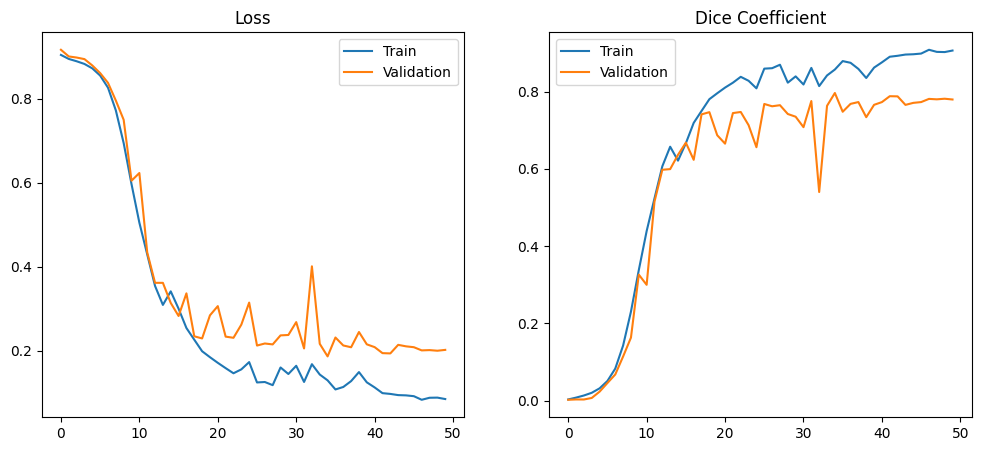

In [ ]:
# plotting loss comparision between training and validation loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['dice_coefficient'])
plt.plot(history.history['val_dice_coefficient'])
plt.title("Dice Coefficient")
plt.legend(["Train", "Validation"])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


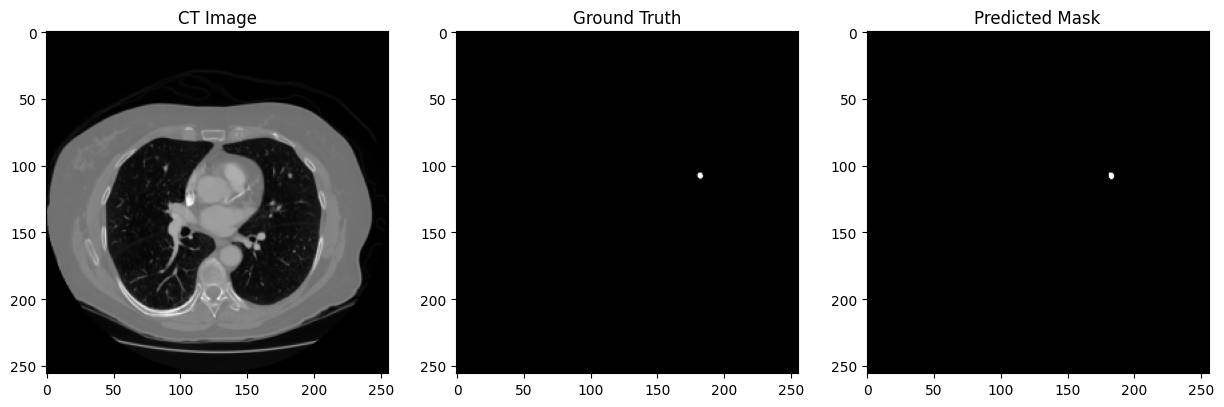

In [ ]:
# validation loss
index = 0

sample_image = X_val[index]
sample_mask = Y_val[index]

prediction = model.predict(
    np.expand_dims(sample_image, axis=0)
)[0]

prediction = (prediction > 0.5).astype(np.uint8)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title("CT Image")

plt.subplot(1,3,2)
plt.imshow(sample_mask.squeeze(), cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(prediction.squeeze(), cmap='gray')
plt.title("Predicted Mask")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


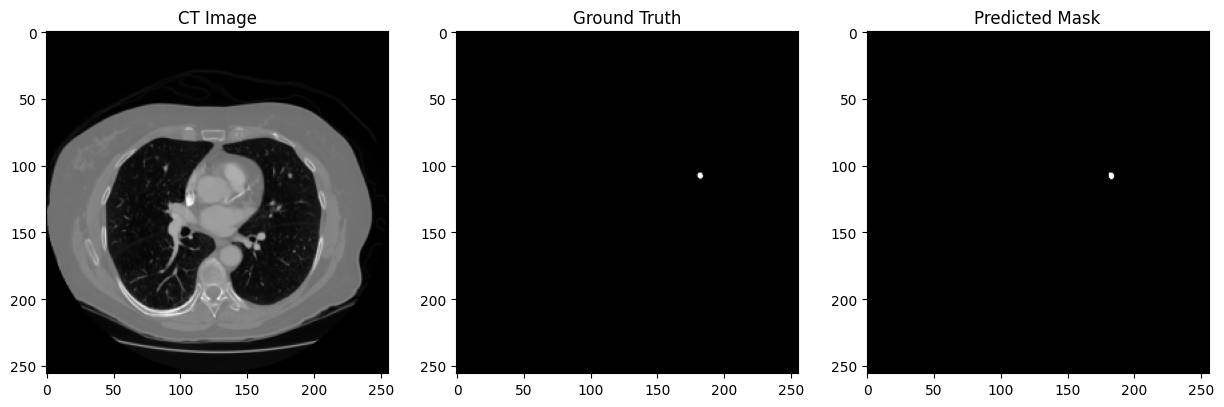

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


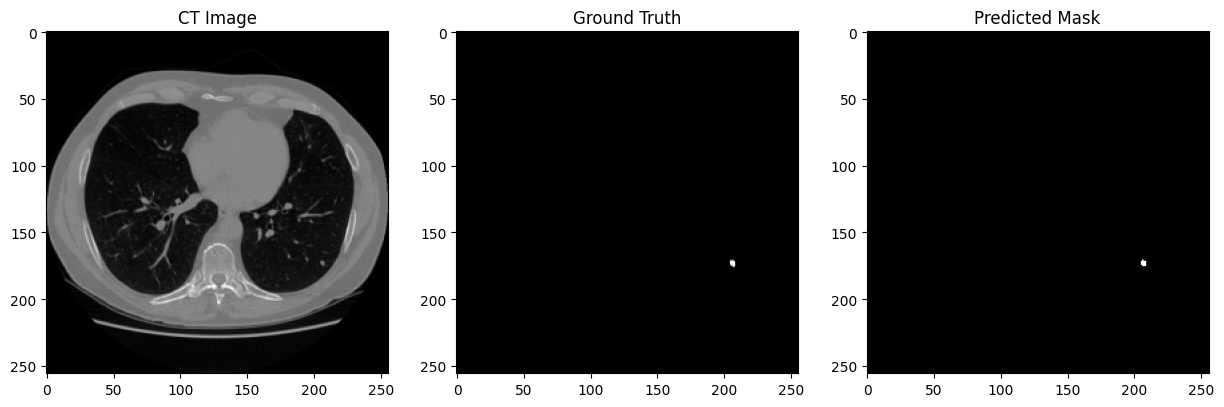

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


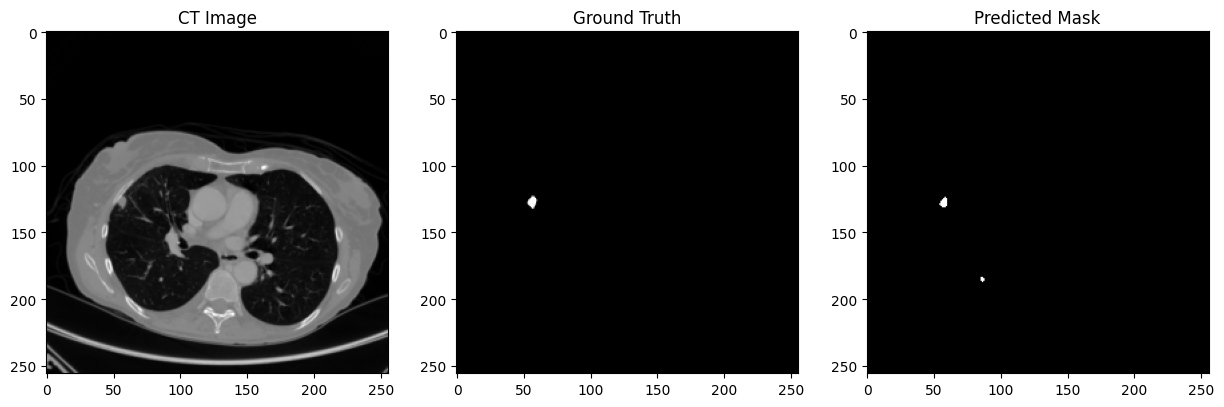

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


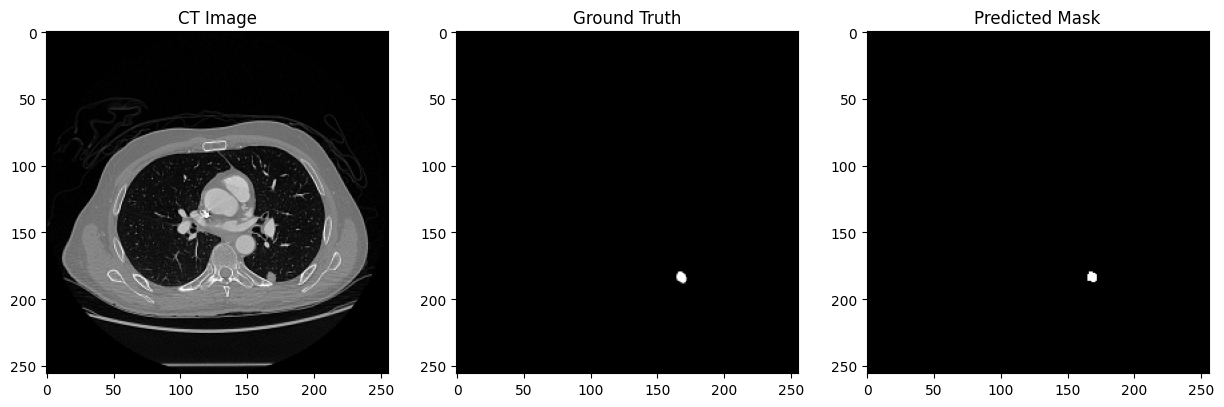

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


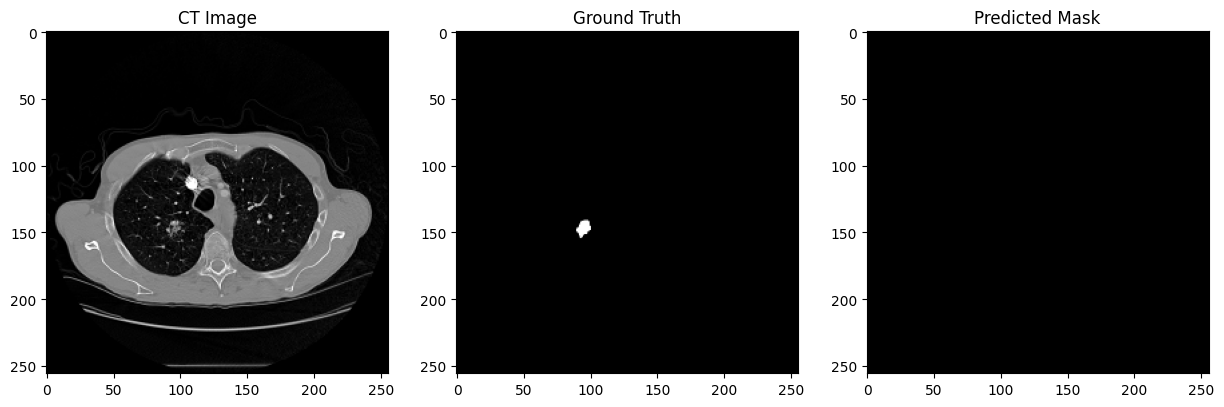

In [ ]:
for i in range(5):
  index = i

  sample_image = X_val[index]
  sample_mask = Y_val[index]

  prediction = model.predict(
      np.expand_dims(sample_image, axis=0)
  )[0]

  prediction = (prediction > 0.5).astype(np.uint8)

  plt.figure(figsize=(15,5))

  plt.subplot(1,3,1)
  plt.imshow(sample_image.squeeze(), cmap='gray')
  plt.title("CT Image")

  plt.subplot(1,3,2)
  plt.imshow(sample_mask.squeeze(), cmap='gray')
  plt.title("Ground Truth")

  plt.subplot(1,3,3)
  plt.imshow(prediction.squeeze(), cmap='gray')
  plt.title("Predicted Mask")

  plt.show()